# Projet ML - Classification des Dechets Recyclables

## 1. Imports & Configuration

In [579]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from scipy import stats

SEED = 42
np.random.seed(SEED)

NUM_COLS = ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Prix_Revente']
TARGET   = 'Categorie'

plt.rcParams.update({'figure.dpi': 100, 'figure.figsize': (10, 4)})
print('Imports OK')


Imports OK


## 2. Chargement & Exploration initiale

In [580]:
df_raw = pd.read_csv("C:\Ml-project\data\dataset_ProjetML_2026.csv", sep=',', header=0)
print(f'Dimensions : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes')

Dimensions : 10500 lignes x 9 colonnes


In [581]:
df_raw.head()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.0,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.0,1.0,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...


In [582]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Poids             9471 non-null   float64
 1   Volume            9960 non-null   float64
 2   Conductivite      9483 non-null   float64
 3   Opacite           9465 non-null   float64
 4   Rigidite          9942 non-null   float64
 5   Prix_Revente      9964 non-null   float64
 6   Categorie         9986 non-null   str    
 7   Source            9964 non-null   str    
 8   Rapport_Collecte  10500 non-null  str    
dtypes: float64(6), str(3)
memory usage: 738.4 KB


In [583]:
df_raw.describe(include='all')


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
count,9471.000000,9960.000000,9483.000000,9465.000000,9942.000000,9964.000000,9986,9964,10500
unique,NaN,NaN,NaN,NaN,NaN,NaN,4,4,9336
top,NaN,NaN,NaN,NaN,NaN,NaN,Plastique,Collecte_Citoyenne,Ferraille ou métal collecté via la collecte ci...
freq,NaN,NaN,NaN,NaN,NaN,NaN,2795,2644,8
mean,77.796501,144.408079,0.207674,1.160388,5.886643,58.587857,NaN,NaN,NaN
std,127.847433,136.384216,0.378934,5.492723,3.087225,720.059089,NaN,NaN,NaN
min,-99.000000,-26.807712,0.000000,0.000037,1.000000,-50.000000,NaN,NaN,NaN
25%,19.751538,44.436897,0.000000,0.196410,3.000000,1.393623,NaN,NaN,NaN
50%,39.193029,88.084217,0.000000,0.553484,5.000000,4.135356,NaN,NaN,NaN
75%,130.497561,240.200023,0.000000,1.000000,9.000000,6.781634,NaN,NaN,NaN


## 3. Gestion des Valeurs Manquantes

In [584]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
miss_df = pd.DataFrame({'Nb manquants': missing, 'Taux (%)': missing_pct})
print(miss_df[miss_df['Nb manquants'] > 0].to_string())


              Nb manquants  Taux (%)
Poids                 1029      9.80
Volume                 540      5.14
Conductivite          1017      9.69
Opacite               1035      9.86
Rigidite               558      5.31
Prix_Revente           536      5.10
Categorie              514      4.90
Source                 536      5.10


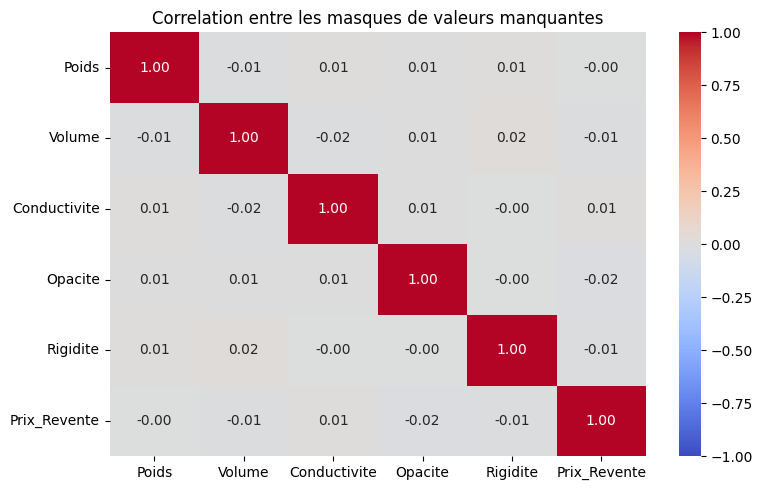

In [585]:
miss_mask = df_raw[NUM_COLS].isnull().astype(int)
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(miss_mask.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation entre les masques de valeurs manquantes')
plt.tight_layout()
plt.show()


### 3.1 Diagnostic - MCAR / MAR / MNAR

In [586]:
for col_miss in NUM_COLS:
    mask = df_raw[col_miss].isnull()
    if mask.sum() == 0:
        continue
    for col_obs in NUM_COLS:
        if col_obs == col_miss or df_raw[col_obs].isnull().all():
            continue
        g1 = df_raw.loc[mask,  col_obs].dropna()
        g2 = df_raw.loc[~mask, col_obs].dropna()
        if len(g1) < 5 or len(g2) < 5:
            continue
        t, p = stats.ttest_ind(g1, g2, equal_var=False)
        sig = 'MAR probable' if p < 0.05 else 'ok (MCAR)'
        print( f'[{col_miss}] vs {col_obs:<15s} -> p={p}  {sig}')
    print()


[Poids] vs Volume          -> p=0.00040004408065106586  MAR probable
[Poids] vs Conductivite    -> p=0.0013516180797559178  MAR probable
[Poids] vs Opacite         -> p=0.30500607612474895  ok (MCAR)
[Poids] vs Rigidite        -> p=0.6361418026195786  ok (MCAR)
[Poids] vs Prix_Revente    -> p=0.0003640711541380805  MAR probable

[Volume] vs Poids           -> p=0.6736427398998516  ok (MCAR)
[Volume] vs Conductivite    -> p=0.5510643483900144  ok (MCAR)
[Volume] vs Opacite         -> p=0.7019552319721305  ok (MCAR)
[Volume] vs Rigidite        -> p=0.8458178755179036  ok (MCAR)
[Volume] vs Prix_Revente    -> p=0.6122706251055506  ok (MCAR)

[Conductivite] vs Poids           -> p=0.2195686552069632  ok (MCAR)
[Conductivite] vs Volume          -> p=0.8114752459090615  ok (MCAR)
[Conductivite] vs Opacite         -> p=0.14448569678761253  ok (MCAR)
[Conductivite] vs Rigidite        -> p=0.2224140849775863  ok (MCAR)
[Conductivite] vs Prix_Revente    -> p=0.00045707170213248445  MAR probable


### 3.2Nettoyage des anomalies avant imputation

In [587]:
df = df_raw.copy()

# Suppression lignes sans cible
n_before = len(df)
df = df.dropna(subset=[TARGET]).reset_index(drop=True)
print(f'Lignes supprimees (cible manquante) : {n_before - len(df)}')
print(f'Lignes restantes : {len(df)}')

# Correction sentinelles
df.loc[df['Poids'] == -99,       'Poids']       = np.nan
df.loc[df['Volume'] < 0,         'Volume']       = np.nan
df.loc[df['Prix_Revente'] == 9999,'Prix_Revente'] = np.nan




Lignes supprimees (cible manquante) : 514
Lignes restantes : 9986


In [588]:
print('\nAnomalies sentinelles corrigees')
print('\nNaN apres nettoyage :\n', df[NUM_COLS].isnull().sum())


Anomalies sentinelles corrigees

NaN apres nettoyage :
 Poids           1073
Volume           748
Conductivite     959
Opacite          992
Rigidite         530
Prix_Revente     564
dtype: int64


### 3.3 Comparaison des strategies d'imputation

## Mediane

Imputation par mediane terminee


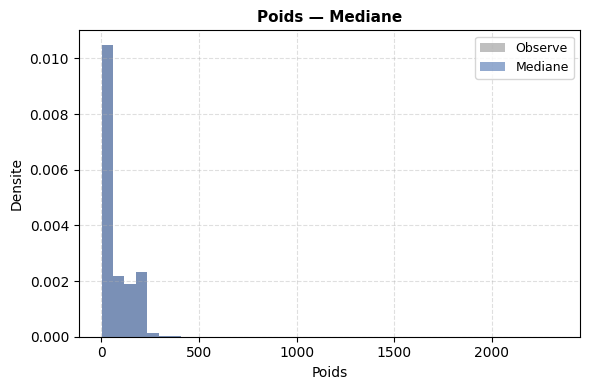

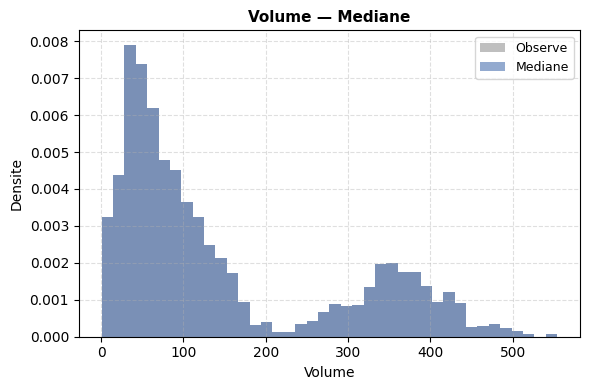

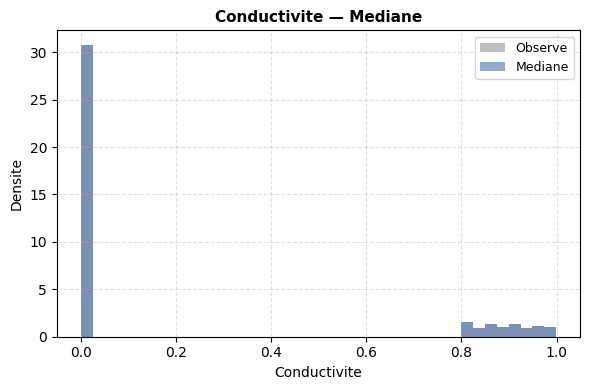

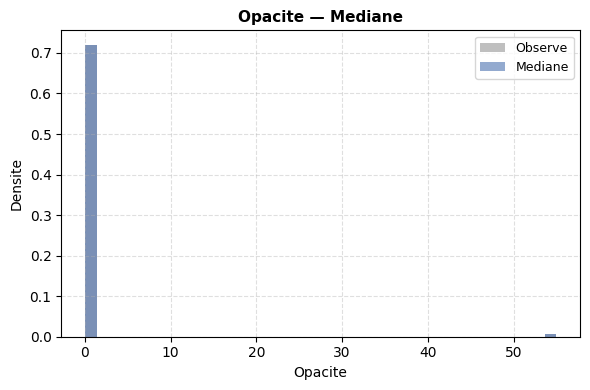

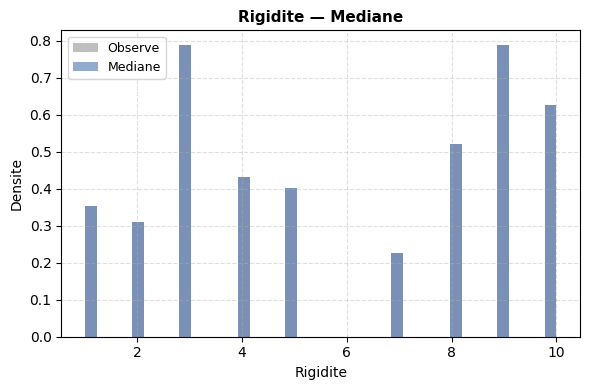

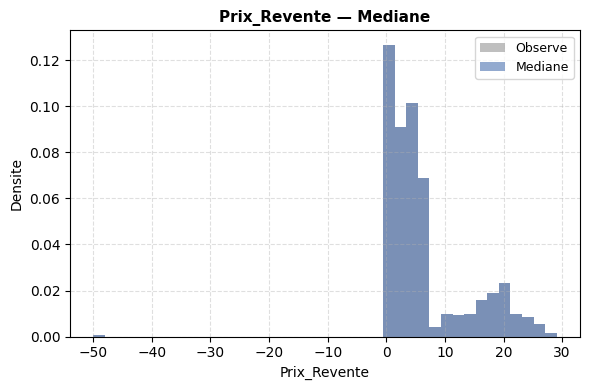

In [589]:
df_median = df.copy()
for col in NUM_COLS:
    df_median[col].fillna(df_median[col].median(), inplace=True)
print('Imputation par mediane terminee')

for col in NUM_COLS:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(orig_vals_dict[col], bins=40, alpha=0.5, color='gray', label='Observe', density=True)
    ax.hist(df_median[col], bins=40, alpha=0.6, color='#4C72B0', label='Mediane', density=True)
    ax.set_title(f'{col} — Mediane', fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Densite')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    

## KNN

KNN Imputer (k=5) termine


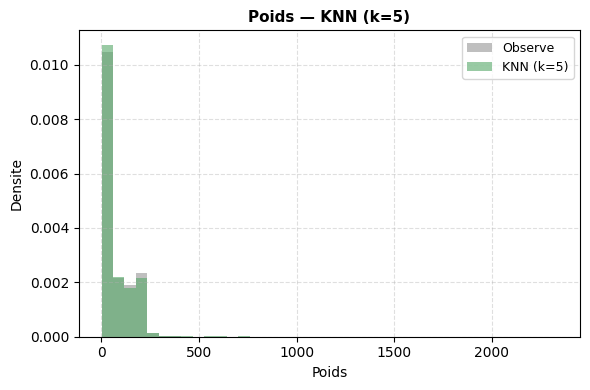

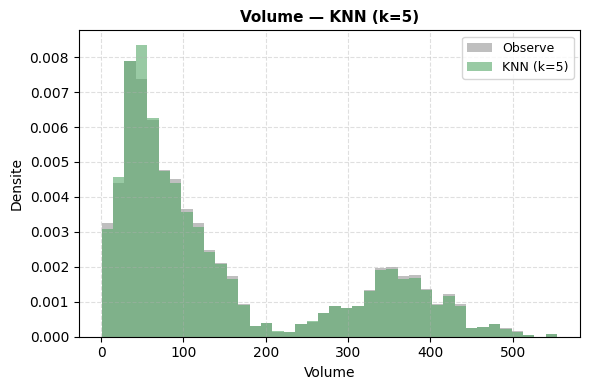

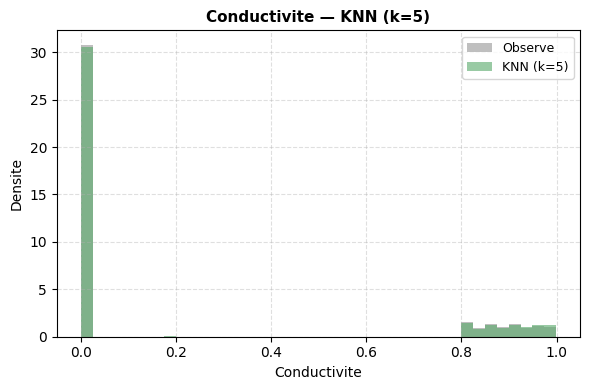

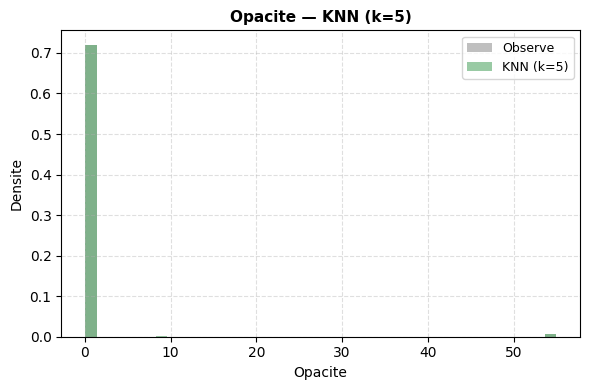

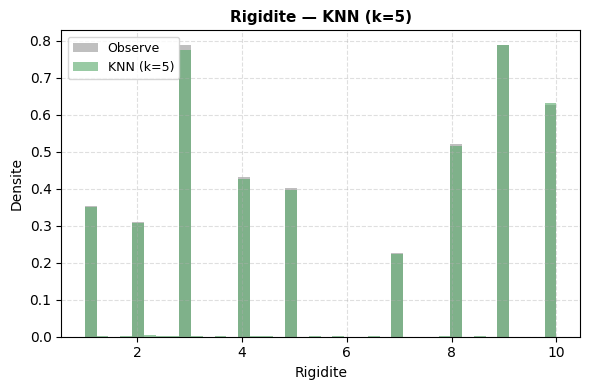

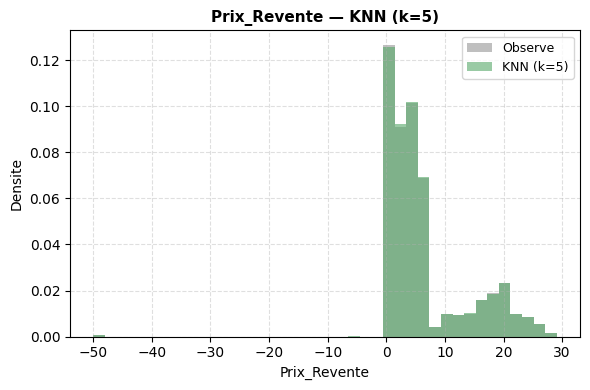

In [590]:
df_knn = df.copy()
knn_imp = KNNImputer(n_neighbors=5, weights='distance')
df_knn[NUM_COLS] = knn_imp.fit_transform(df_knn[NUM_COLS])
print('KNN Imputer (k=5) termine')

for col in NUM_COLS:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(orig_vals_dict[col], bins=40, alpha=0.5, color='gray', label='Observe', density=True)
    ax.hist(df_knn[col], bins=40, alpha=0.6, color='#55A868', label='KNN (k=5)', density=True)
    ax.set_title(f'{col} — KNN (k=5)', fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Densite')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

## Iterative

Iterative Imputer termine


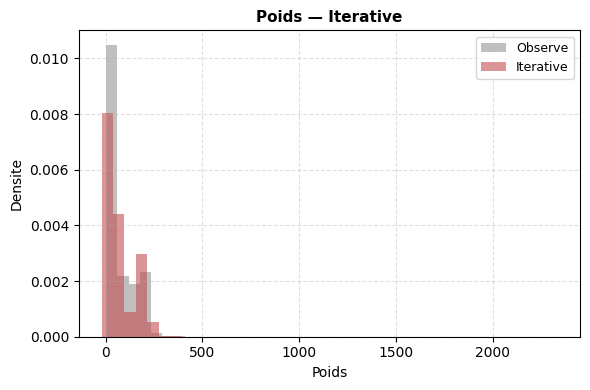

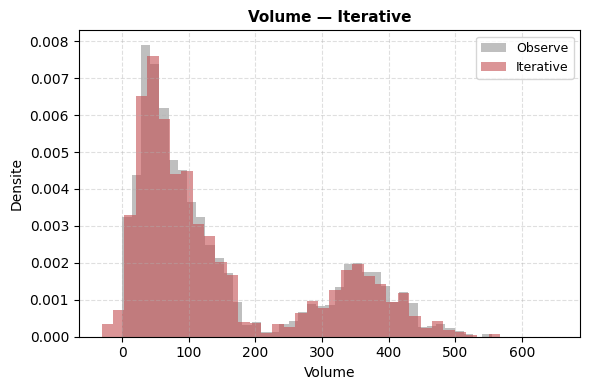

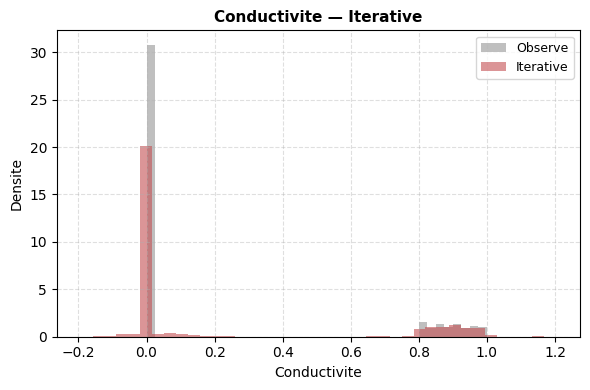

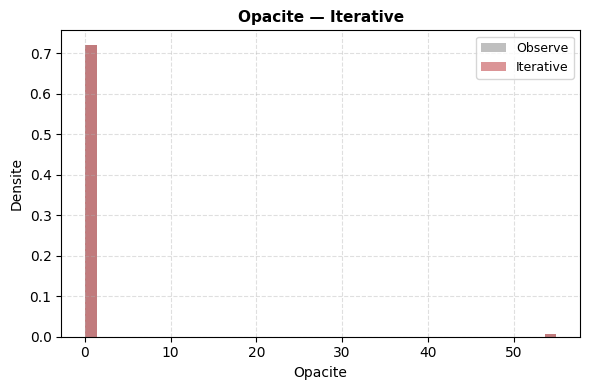

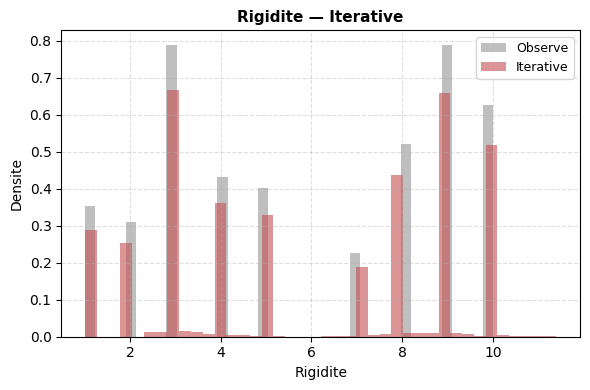

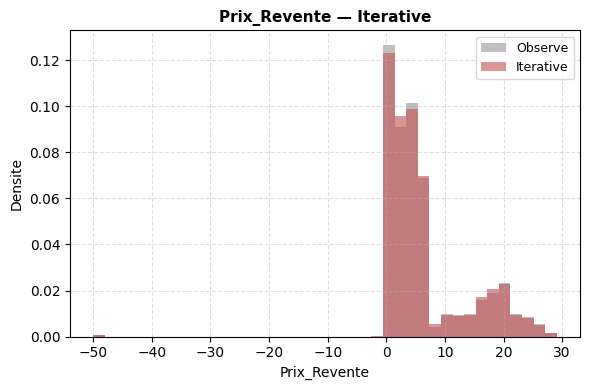

In [591]:
df_iter = df.copy()
iter_imp = IterativeImputer(random_state=SEED, max_iter=10)
df_iter[NUM_COLS] = iter_imp.fit_transform(df_iter[NUM_COLS])
print('Iterative Imputer termine')

for col in NUM_COLS:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(orig_vals_dict[col], bins=40, alpha=0.5, color='gray', label='Observe', density=True)
    ax.hist(df_iter[col], bins=40, alpha=0.6, color='#C44E52', label='Iterative', density=True)
    ax.set_title(f'{col} — Iterative', fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Densite')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

## Visualisation comparative des distributions

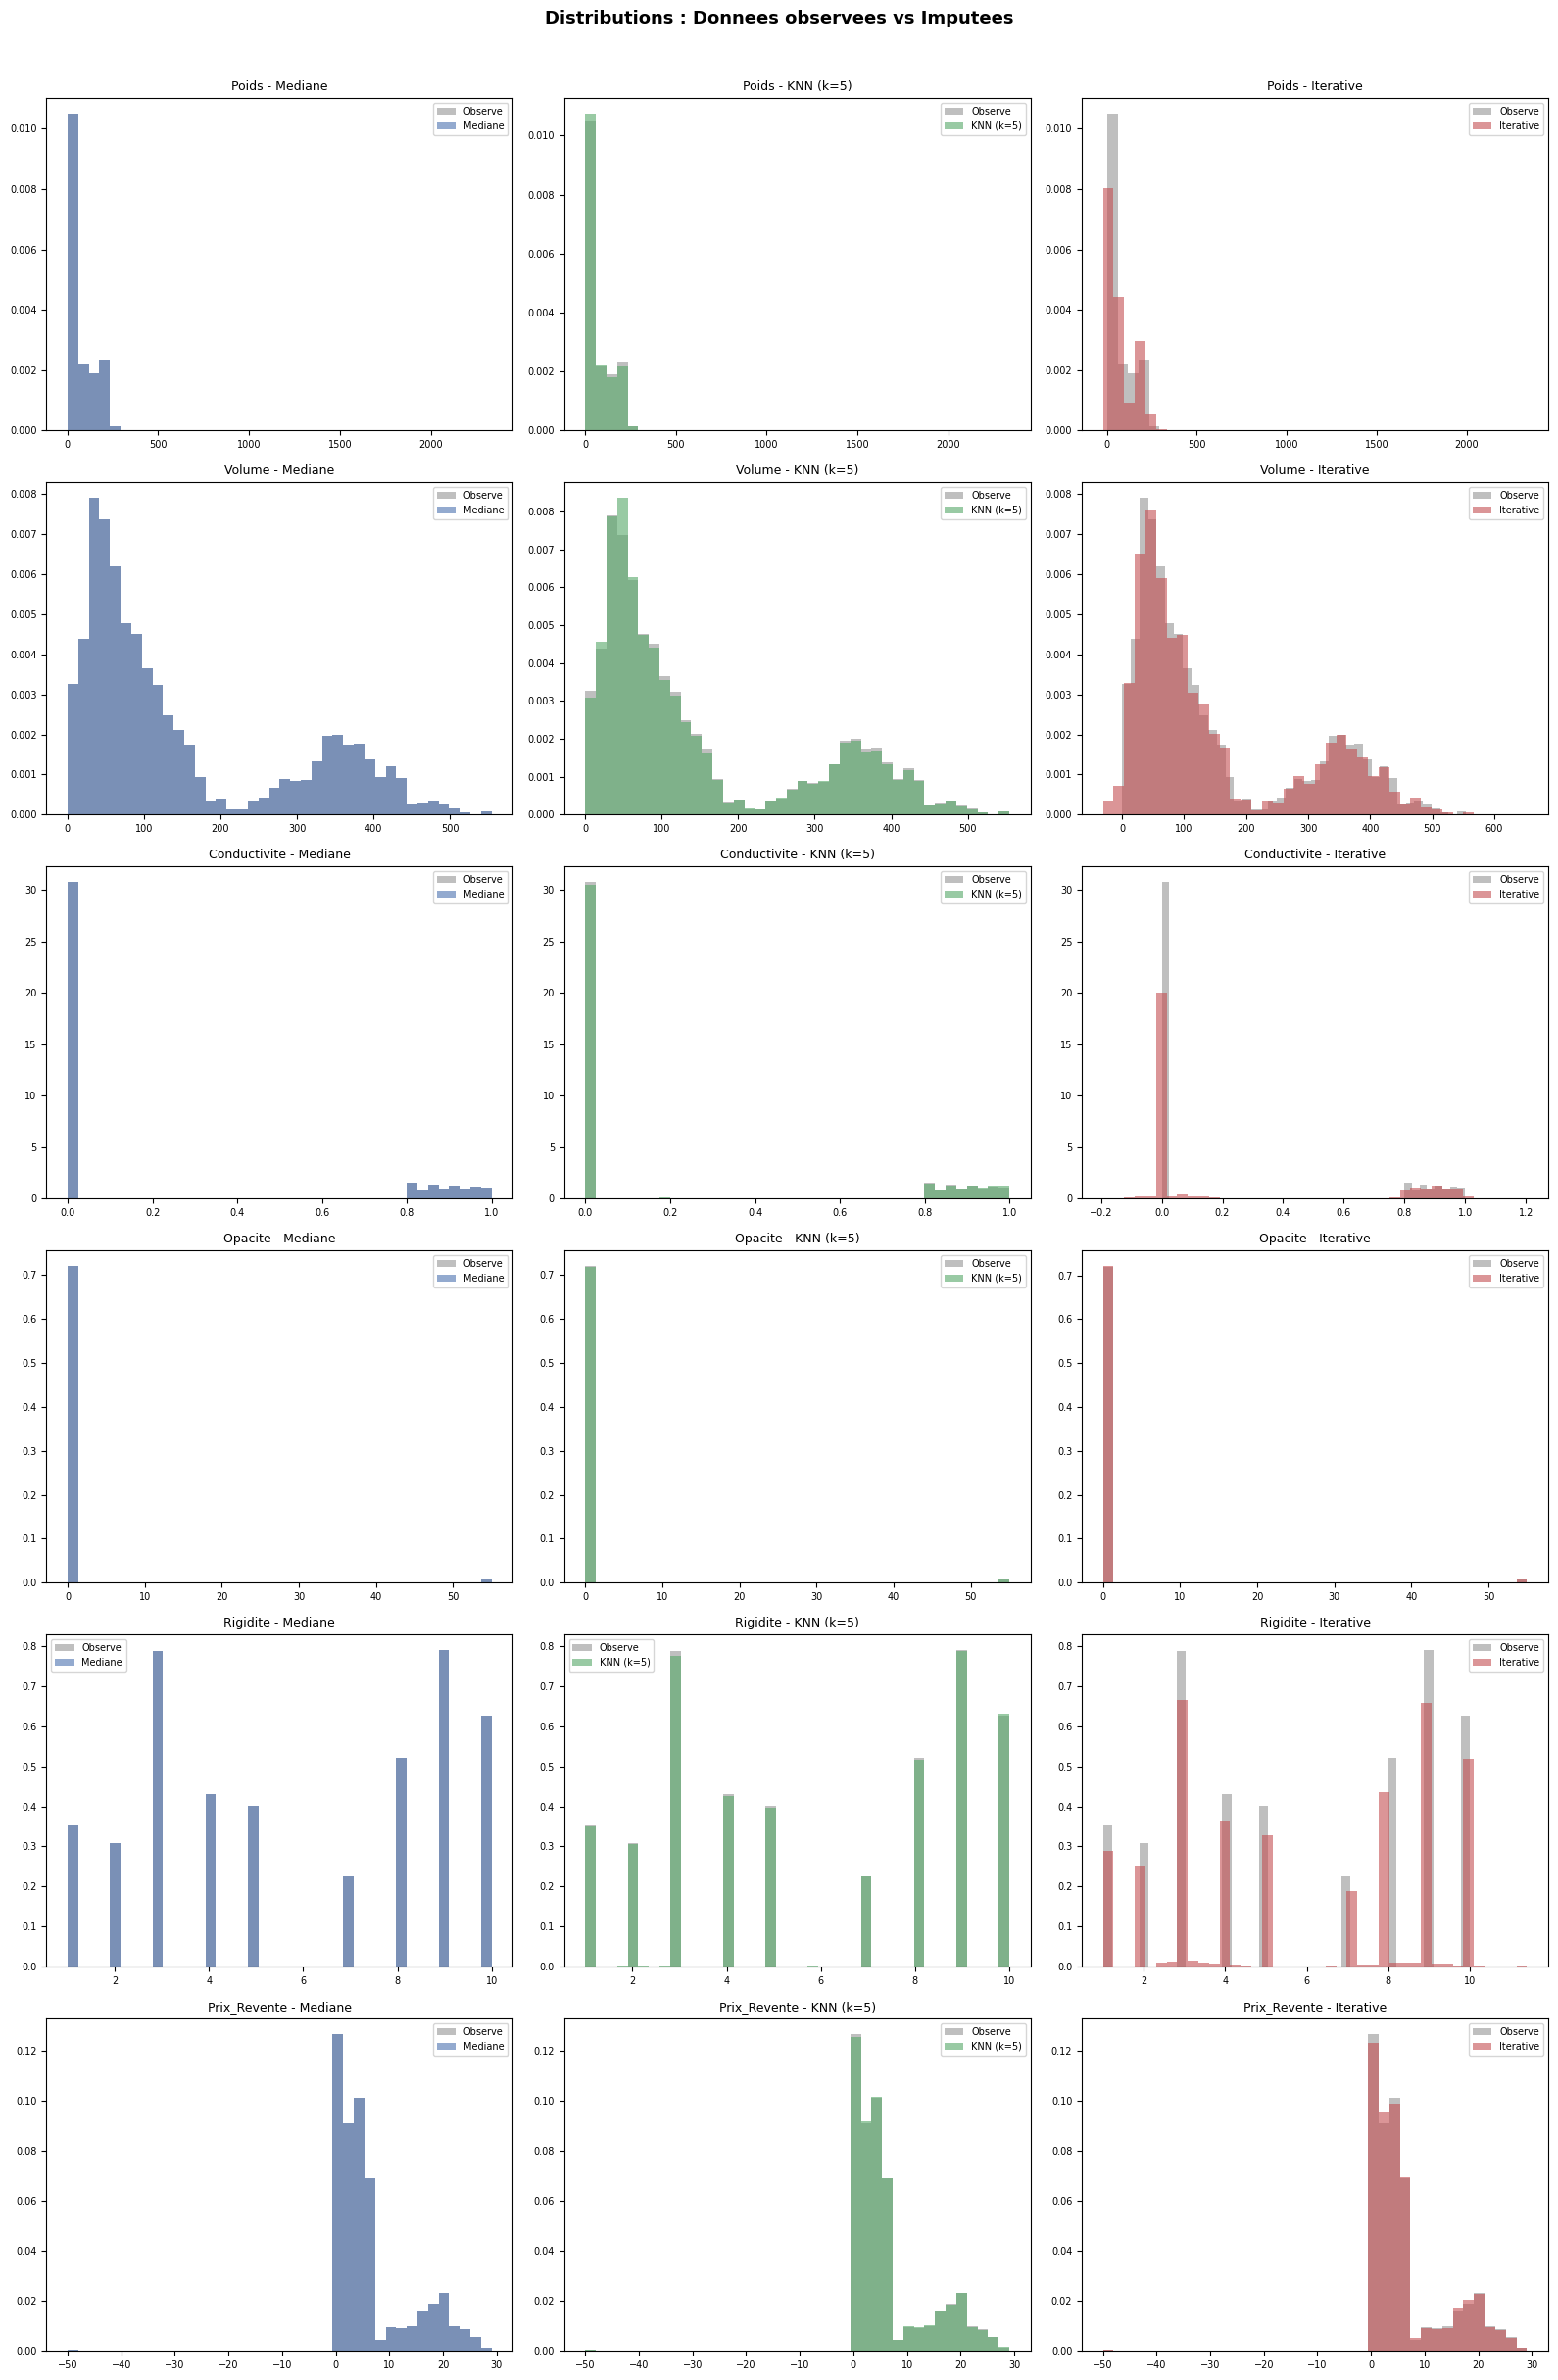

In [592]:
fig, axes = plt.subplots(len(NUM_COLS), 3, figsize=(16, 4 * len(NUM_COLS)))
methods = ['Mediane', 'KNN (k=5)', 'Iterative']
dfs_imp = [df_median, df_knn, df_iter]
colors  = ['#4C72B0', '#55A868', '#C44E52']

for i, col in enumerate(NUM_COLS):
    orig_vals = df[col].dropna()
    for j, (name, dfi, color) in enumerate(zip(methods, dfs_imp, colors)):
        ax = axes[i][j]
        ax.hist(orig_vals, bins=40, alpha=0.5, color='gray', label='Observe', density=True)
        ax.hist(dfi[col],  bins=40, alpha=0.6, color=color,  label=name,     density=True)
        ax.set_title(f'{col} - {name}', fontsize=9)
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=7)

plt.suptitle('Distributions : Donnees observees vs Imputees', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [593]:
from scipy.stats import wasserstein_distance

print(f"{'Variable':<18} {'Mediane':>12} {'KNN':>12} {'Iterative':>12}")
print('-' * 56)
for col in NUM_COLS:
    orig = df[col].dropna().values
    scores = []
    for dfi in [df_median, df_knn, df_iter]:
        imp_vals = dfi.loc[df[col].isnull(), col].values
        w = wasserstein_distance(orig, imp_vals) if len(imp_vals) > 0 else 0.0
        scores.append(w)
    best = np.argmin(scores)
    row = f'{col:<18}'
    for k, s in enumerate(scores):
        marker = '' if k == best else '   '
        row += f' {s:>10.4f}{marker}'
    print(row)



Variable                Mediane          KNN    Iterative
--------------------------------------------------------
Poids                     nan    31.7474       11.5863   
Volume                    nan    37.3652       32.0183   
Conductivite              nan     0.0395        0.0986   
Opacite                   nan     0.2502        1.1171   
Rigidite                  nan     0.1540        0.4721   
Prix_Revente              nan     0.6055        0.9587   


## en va travailler avec Iterative parceque la distance Wasserstein et le plus  minimale

In [594]:
df_clean = df_iter.copy()
print('\nNaN residuels :\n', df_clean[NUM_COLS].isnull().sum())



NaN residuels :
 Poids           0
Volume          0
Conductivite    0
Opacite         0
Rigidite        0
Prix_Revente    0
dtype: int64


## 4. Traitement des Outliers


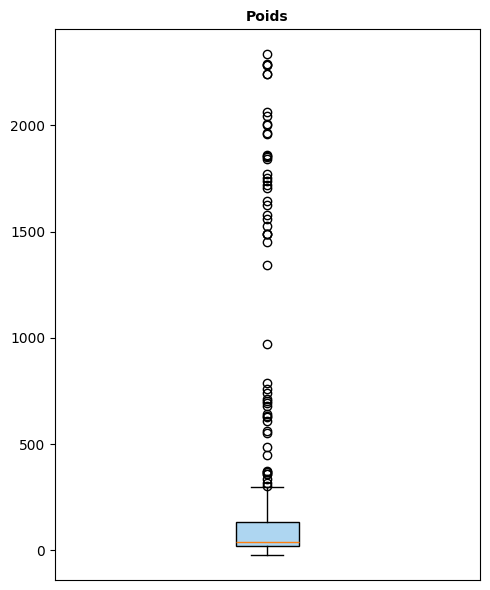

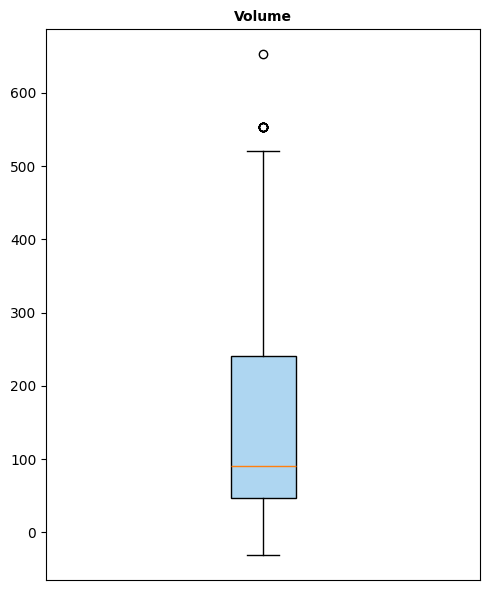

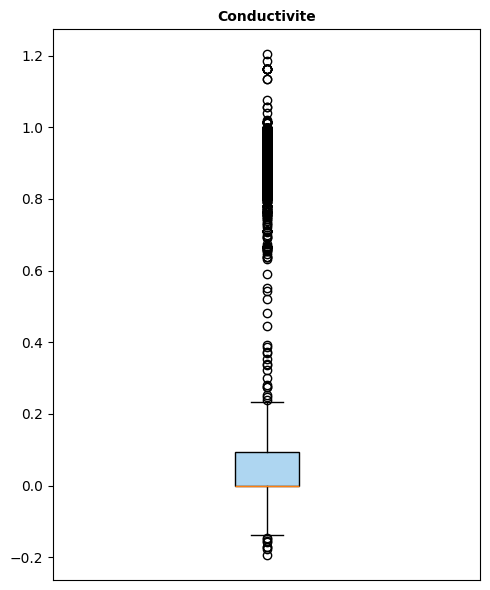

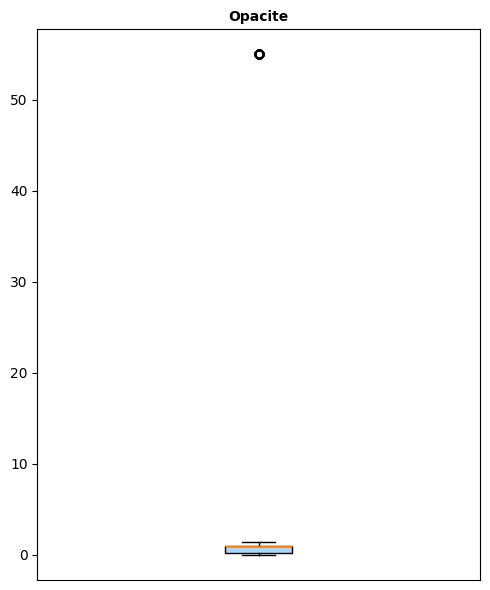

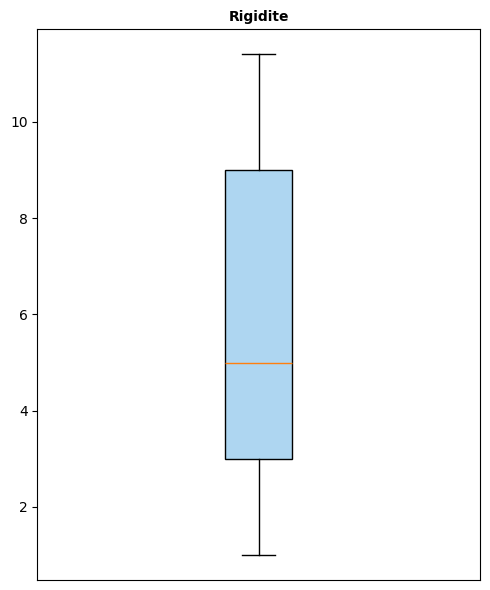

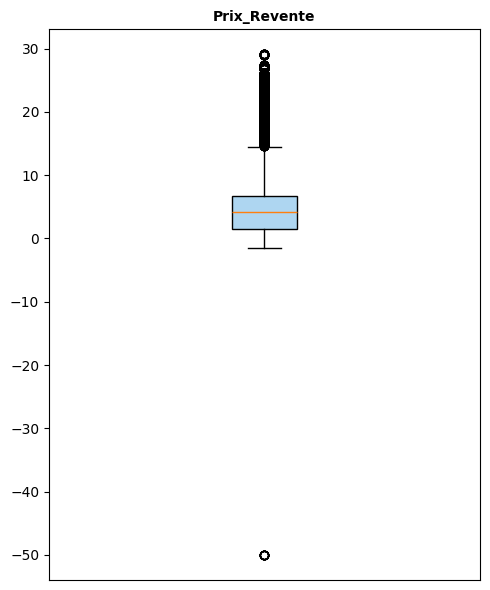

In [595]:
import matplotlib.pyplot as plt

for col in NUM_COLS:
    plt.figure(figsize=(5, 6)) 
    plt.boxplot(df_clean[col].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='#AED6F1'))
    plt.title(col, fontsize=10, fontweight='bold')
    plt.xticks([]) 
    plt.tight_layout()
    plt.show()  

In [596]:
def cap_outliers_iqr(df, cols, factor=1.5):
    df_out = df.copy()
    report = {}
    for col in cols:
        Q1  = df_out[col].quantile(0.25)
        Q3  = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lb  = Q1 - factor * IQR
        ub  = Q3 + factor * IQR
        n_out = ((df_out[col] < lb) | (df_out[col] > ub)).sum()
        df_out[col] = df_out[col].clip(lb, ub)
        report[col] = {'Q1': round(Q1,3), 'Q3': round(Q3,3),
                       'Borne inf': round(lb,3), 'Borne sup': round(ub,3),
                       'Nb cappes': n_out}
    return df_out, pd.DataFrame(report).T

df_clean, outlier_report = cap_outliers_iqr(df_clean, NUM_COLS)
print('=== Rapport IQR Capping ===')
print(outlier_report.to_string())
print(f'\nTotal valeurs cappees : {outlier_report["Nb cappes"].sum():.0f}')


=== Rapport IQR Capping ===
                  Q1       Q3  Borne inf  Borne sup  Nb cappes
Poids         20.398  132.139   -147.213    299.751       55.0
Volume        47.308  241.083   -243.354    531.746       12.0
Conductivite   0.000    0.095     -0.143      0.238     2306.0
Opacite        0.233    1.000     -0.918      2.151       93.0
Rigidite       3.000    9.000     -6.000     18.000        0.0
Prix_Revente   1.527    6.708     -6.244     14.480     1735.0

Total valeurs cappees : 4201


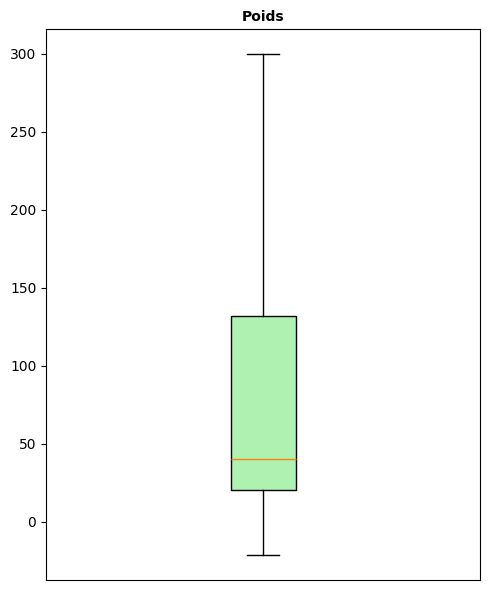

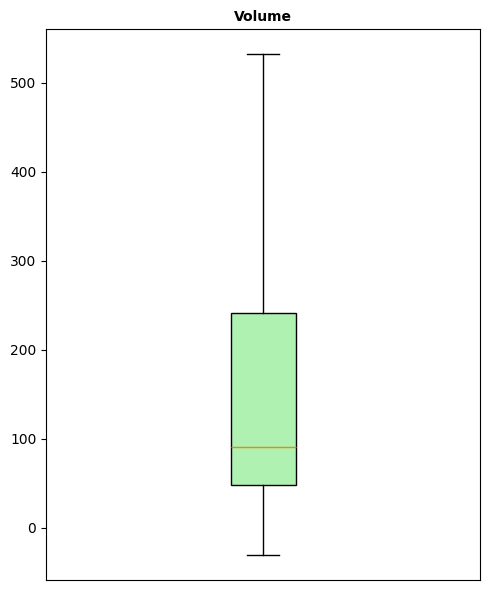

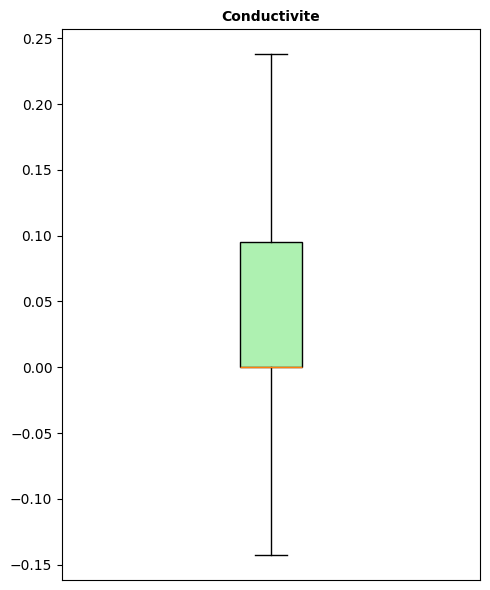

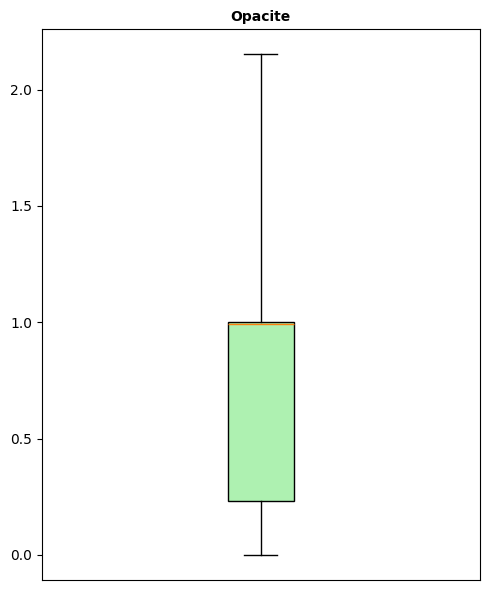

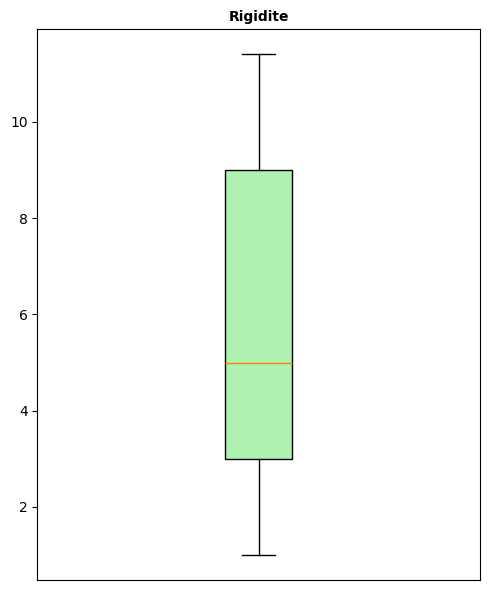

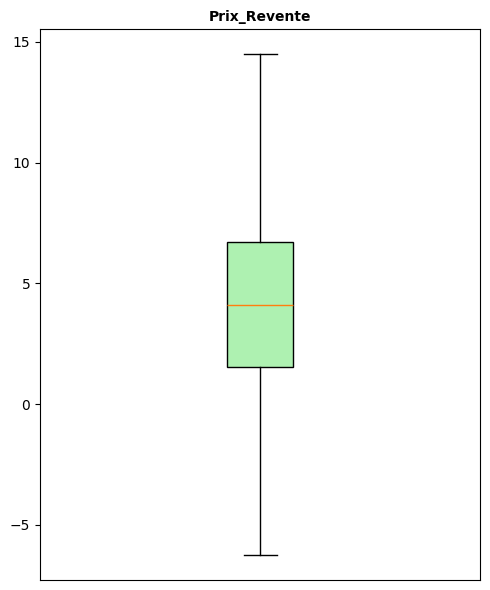

In [597]:
import matplotlib.pyplot as plt

for col in NUM_COLS:
    plt.figure(figsize=(5, 6)) 
    plt.boxplot(df_clean[col].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor="#AEF1B1"))
    plt.title(col, fontsize=10, fontweight='bold')
    plt.xticks([]) 
    plt.tight_layout()
    plt.show() 

# 5. Feature Engineering

### 5.1 Creation de nouvelles features

In [598]:
df_clean['Densite'] = (df_clean['Poids'] /
                       df_clean['Volume'].replace(0, np.nan))
df_clean['Densite'].fillna(df_clean['Densite'].median(), inplace=True)

df_clean['Cond_Opac_ratio'] = (df_clean['Conductivite'] /
                                (df_clean['Opacite'] + 1e-6))

df_clean['Valeur_Vol'] = (df_clean['Prix_Revente'] /
                          df_clean['Volume'].replace(0, np.nan))
df_clean['Valeur_Vol'].fillna(df_clean['Valeur_Vol'].median(), inplace=True)

NEW_FEATURES = ['Densite', 'Cond_Opac_ratio', 'Valeur_Vol']
ALL_NUM_COLS = NUM_COLS + NEW_FEATURES

print(f'{len(NEW_FEATURES)} nouvelles features : {NEW_FEATURES}')
print(f'\nDimensions : {df_clean.shape}')
df_clean[ALL_NUM_COLS].describe().round(3)


3 nouvelles features : ['Densite', 'Cond_Opac_ratio', 'Valeur_Vol']

Dimensions : (9986, 12)


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Densite,Cond_Opac_ratio,Valeur_Vol
count,9986.000,9986.000,9986.000,9986.000,9986.000,9986.000,9986.000,9986.000,9986.000
mean,74.022,146.208,0.057,0.672,5.897,5.527,0.674,0.068,0.060
std,70.901,134.526,0.102,0.436,3.073,4.900,2.247,0.338,0.114
min,-21.205,-30.788,-0.143,0.000,1.000,-6.244,-16.936,-5.115,-5.081
25%,20.398,47.308,0.000,0.233,3.000,1.527,0.422,0.000,0.015
50%,40.501,90.177,0.000,0.994,5.000,4.112,0.496,0.000,0.036
75%,132.139,241.083,0.095,1.000,9.000,6.708,0.554,0.194,0.088
max,299.751,531.746,0.238,2.151,11.404,14.480,162.035,15.900,4.270


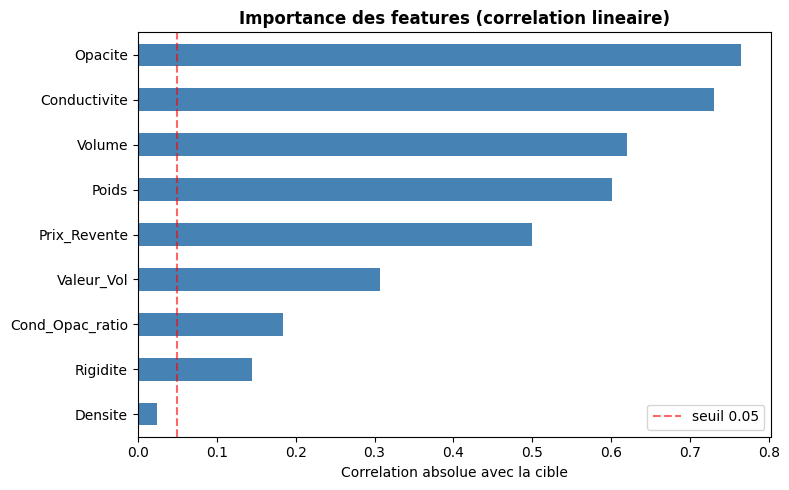

In [599]:
# Correlation des features avec la cible
le_tmp = LabelEncoder()
target_enc = le_tmp.fit_transform(df_clean[TARGET])

corrs = {col: abs(np.corrcoef(df_clean[col], target_enc)[0, 1])
         for col in ALL_NUM_COLS}
corr_series = pd.Series(corrs).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
corr_series.plot(kind='barh', color='steelblue', ax=ax)
ax.set_xlabel('Correlation absolue avec la cible')
ax.set_title('Importance des features (correlation lineaire)', fontweight='bold')
ax.axvline(0.05, color='red', linestyle='--', alpha=0.6, label='seuil 0.05')
ax.legend()
plt.tight_layout()
plt.show()


### 5.2 Normalisation / Standardisation

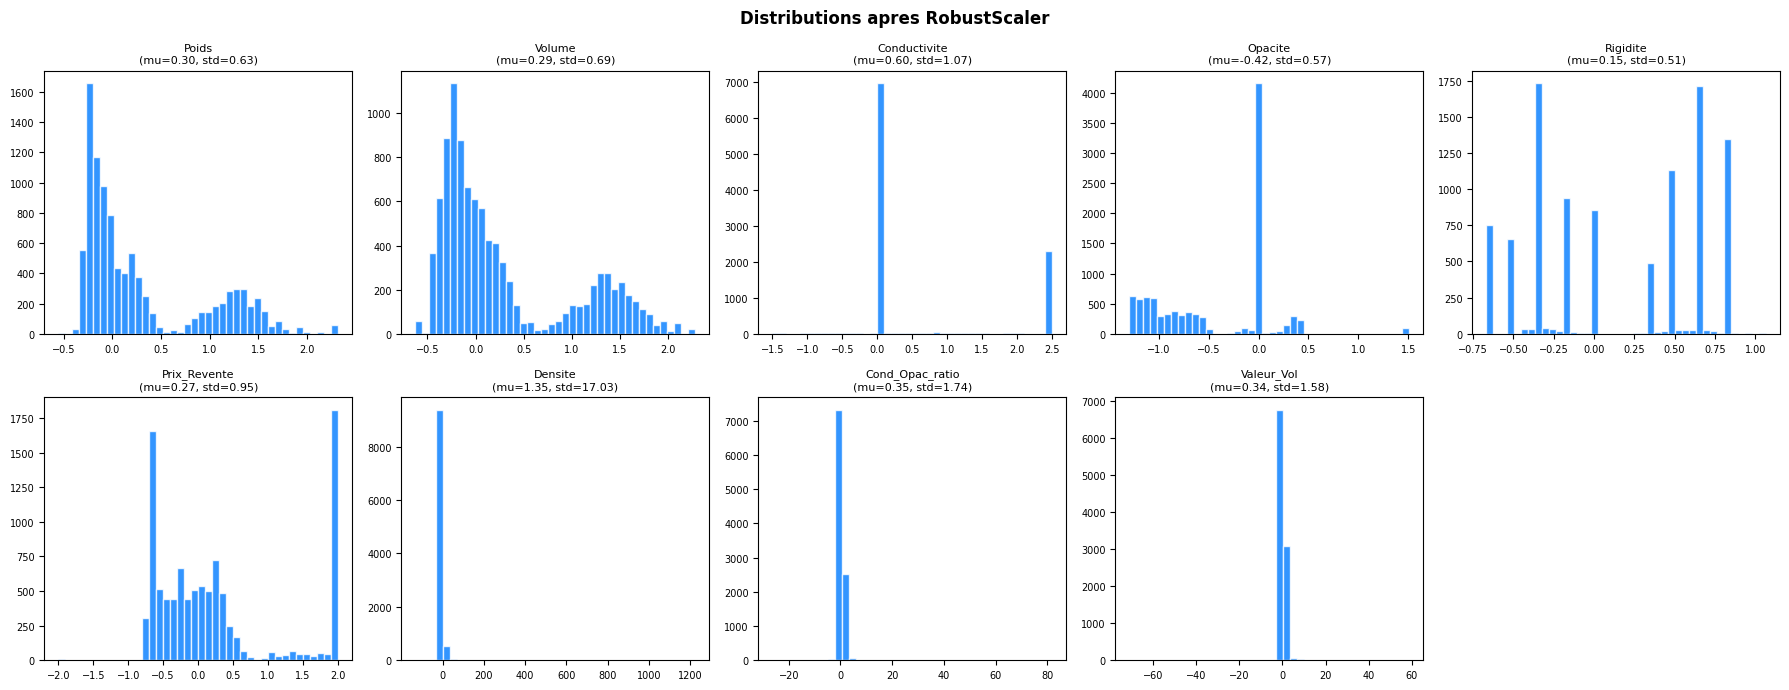

In [600]:
scaler = RobustScaler()
df_scaled = df_clean.copy()
df_scaled[ALL_NUM_COLS] = scaler.fit_transform(df_clean[ALL_NUM_COLS])

# Visualisation des distributions apres scaling
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
for i, col in enumerate(ALL_NUM_COLS):
    axes[i].hist(df_scaled[col], bins=40, color="#007BFF",
                 edgecolor='white', alpha=0.8)
    axes[i].set_title(
        f'{col}\n(mu={df_scaled[col].mean():.2f}, std={df_scaled[col].std():.2f})',
        fontsize=8)
    axes[i].tick_params(labelsize=7)
for ax in axes[len(ALL_NUM_COLS):]:
    ax.set_visible(False)
plt.suptitle('Distributions apres RobustScaler', fontweight='bold')
plt.tight_layout()
plt.show()


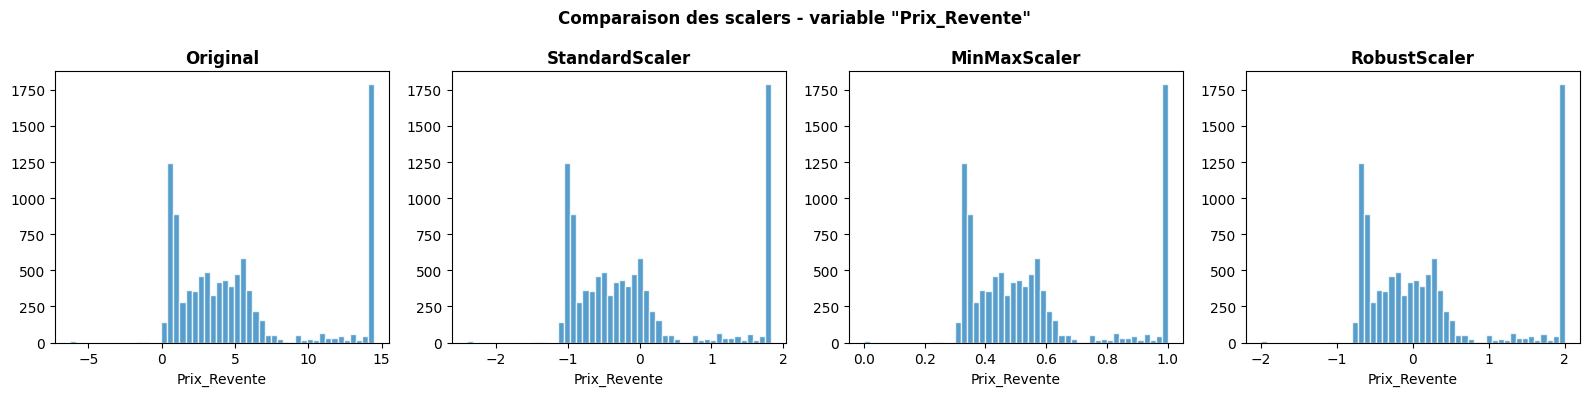

In [601]:
# Comparaison visuelle des 3 scalers sur Prix_Revente
col_demo = 'Prix_Revente'
scalers_demo = {
    'Original':       df_clean[col_demo].values,
    'StandardScaler': StandardScaler().fit_transform(df_clean[[col_demo]]).flatten(),
    'MinMaxScaler':   MinMaxScaler().fit_transform(df_clean[[col_demo]]).flatten(),
    'RobustScaler':   RobustScaler().fit_transform(df_clean[[col_demo]]).flatten(),
}
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, vals) in zip(axes, scalers_demo.items()):
    ax.hist(vals, bins=50, color='#2E86C1', edgecolor='white', alpha=0.8)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel(col_demo)
plt.suptitle(f'Comparaison des scalers - variable "{col_demo}"', fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Encodage des Variables Categoriques

In [602]:
# Encodage de la cible
le = LabelEncoder()
df_scaled[TARGET] = le.fit_transform(df_scaled[TARGET])

print('=== Encodage de la cible ===')
for i, cls in enumerate(le.classes_):
    print(f'  {i} -> {cls}')
print(f'\nDistribution encodee :\n{pd.Series(df_scaled[TARGET]).value_counts().sort_index()}')


=== Encodage de la cible ===
  0 -> Métal
  1 -> Papier
  2 -> Plastique
  3 -> Verre

Distribution encodee :
Categorie
0    2287
1    2318
2    2795
3    2586
Name: count, dtype: int64


In [603]:
# Encodage de Source : One-Hot (NaN -> 'Inconnu')
df_scaled['Source'] = df_scaled['Source'].fillna('Inconnu')
df_scaled = pd.get_dummies(df_scaled, columns=['Source'], prefix='Source', dtype=int)

source_cols = [c for c in df_scaled.columns if c.startswith('Source_')]
print(f'Colonnes Source creees : {source_cols}')

# Suppression Rapport_Collecte (texte libre)
df_scaled.drop(columns=['Rapport_Collecte'], inplace=True)

print(f'\nDimensions finales : {df_scaled.shape}')
print('\nApercu :')
df_scaled.head(3)


Colonnes Source creees : ['Source_Centre_Tri', 'Source_Collecte_Citoyenne', 'Source_Inconnu', 'Source_Usine_A', 'Source_Usine_B']

Dimensions finales : (9986, 15)

Apercu :


,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Densite,Cond_Opac_ratio,Valeur_Vol,Source_Centre_Tri,Source_Collecte_Citoyenne,Source_Inconnu,Source_Usine_A,Source_Usine_B
0,-0.212927,-0.099267,0.0,0.007930,-0.666667,-0.632347,1,-1.971141,0.0,-0.331255,0,0,1,0,0
1,0.060641,-0.131460,0.0,0.352757,-0.333333,0.118918,2,1.781854,0.0,0.517856,0,0,0,1,0
2,1.215840,1.172693,0.0,-0.046523,0.666667,0.019331,3,0.454919,0.0,-0.310579,0,0,0,0,1


## Section 7 — Normalisation / Standardisation

In [604]:
from sklearn.preprocessing import RobustScaler

# Colonnes à scaler (numériques + métriques textuelles continues)
scale_cols = NUM_COLS + ['rapport_len', 'rapport_word_count']

scaler = RobustScaler()

# Copies pour ne pas altérer les splits originaux
X_train_sc = X_train.copy()
X_val_sc   = X_val.copy()
X_test_sc  = X_test.copy()

# Fit sur train UNIQUEMENT — transform sur val et test
X_train_sc[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val_sc[scale_cols]   = scaler.transform(X_val[scale_cols])
X_test_sc[scale_cols]  = scaler.transform(X_test[scale_cols])

print("Statistiques après RobustScaler (Train) :")
print(X_train_sc[scale_cols[:6]].describe().round(3))

Statistiques après RobustScaler (Train) :
          Poids    Volume  Conductivite   Opacite  Rigidite  Prix_Revente
count  6263.000  6466.000      6339.000  6289.000  6617.000      6587.000
mean      0.364     0.274         0.208     0.707     0.149         0.436
std       1.202     0.645         0.379     6.588     0.514         1.350
min      -0.336    -0.427         0.000    -0.686    -0.667       -10.290
25%      -0.172    -0.211         0.000    -0.443    -0.333        -0.518
50%       0.000     0.000         0.000     0.000     0.000         0.000
75%       0.828     0.789         0.000     0.557     0.667         0.482
max      20.039     2.196         0.999    67.647     0.833         4.748


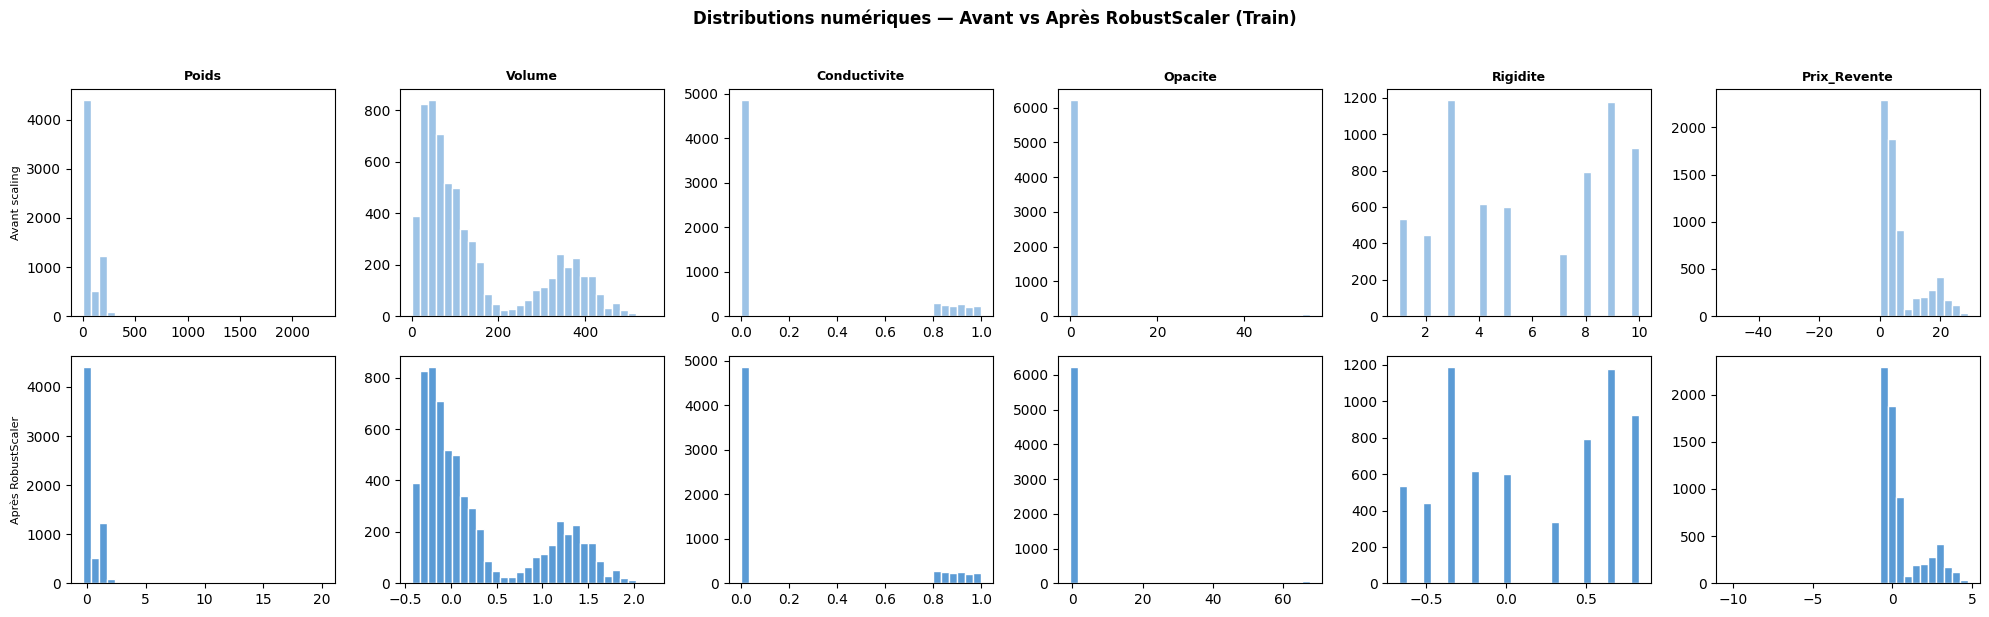

In [605]:
fig, axes = plt.subplots(2, 6, figsize=(20, 6))
for j, col in enumerate(NUM_COLS):
    # Avant
    axes[0, j].hist(X_train[col], bins=30, color='#9DC3E6', edgecolor='white')
    axes[0, j].set_title(col, fontsize=9, fontweight='bold')
    if j == 0:
        axes[0, j].set_ylabel('Avant scaling', fontsize=8)

    # Après
    axes[1, j].hist(X_train_sc[col], bins=30, color='#5B9BD5', edgecolor='white')
    if j == 0:
        axes[1, j].set_ylabel('Après RobustScaler', fontsize=8)

plt.suptitle('Distributions numériques — Avant vs Après RobustScaler (Train)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()